In [10]:
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader 
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as v2
from torchvision.models import resnet18
from torch.optim import SGD, Adam
import seaborn as sns

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import random

def seed(seed=123456789):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


BLUEBERRY_ROOT = Path.home() / "BLUEBERRY_DATA"
CLASSIFICATION_ROOT =  BLUEBERRY_ROOT / "CLASSIFICATION"

transforms = v2.Compose([
  v2.Resize((64, 64)),
  v2.ToImage(),
  # v2.CenterCrop(),

  v2.ToDtype(torch.float32, scale=True)
])


In [11]:
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {DEVICE} device")

lr = 1e-3
BATCH_SIZE = 128
EPOCHS = 1

Using cuda device


In [12]:
# quick and dirty
# def compute_confusion_matrix(model, loader, num_classes):
#     model.eval()
    
#     all_preds = []
#     all_labels = []

#     with torch.no_grad():
#         for images, labels in loader:
#             images = images.to(DEVICE)
#             outputs = model(images)

#             _, preds = torch.max(outputs, 1)

#             all_preds.extend(preds.cpu().numpy())
#             all_labels.extend(labels.numpy())

#     cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
#     return cm

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

In [13]:
g = torch.Generator().manual_seed(0)
seed()
dataset = ImageFolder(CLASSIFICATION_ROOT, transform=transforms)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=8, worker_init_fn=seed_worker, generator=g)
# print(dataset)
# print(dataloader)


num_classes = len(dataset.classes)
model = resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=lr)

loss: 2.254592 | acc: 10.94 % [    0 / 1040134 ]
loss: 0.444183 | acc: 83.59 % [128000 / 1040134 ]
loss: 0.336097 | acc: 88.28 % [256000 / 1040134 ]
loss: 0.407102 | acc: 88.28 % [384000 / 1040134 ]
loss: 0.378203 | acc: 88.28 % [512000 / 1040134 ]
loss: 0.324641 | acc: 87.50 % [640000 / 1040134 ]
loss: 0.380563 | acc: 86.72 % [768000 / 1040134 ]
loss: 0.372520 | acc: 82.03 % [896000 / 1040134 ]
loss: 0.295014 | acc: 90.62 % [1024000 / 1040134 ]


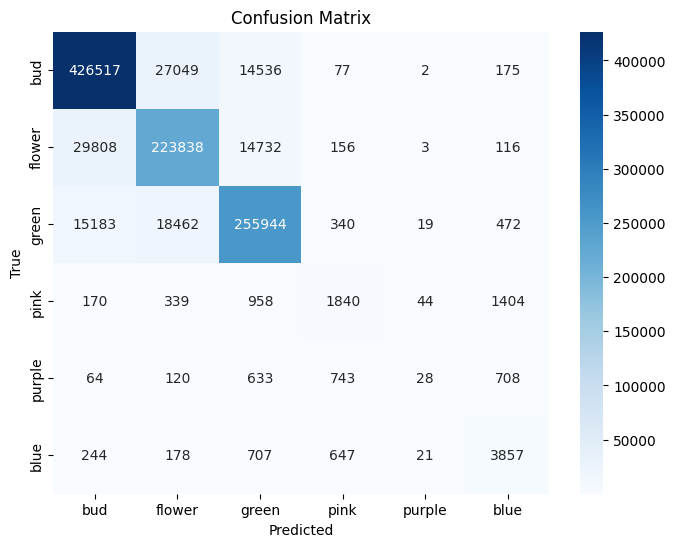

Epoch 0 Loss = 0.332118 | Accuracy = 87.680853 %


In [14]:
# ** TODO: MAKE SURE THIS DOES WHAT I THINK! e.g. that the order is correct
class_names = ["bud", "flower", "green", "pink", "purple", "blue"]
lossi = []
acci = []
for epoch in range(EPOCHS):
  # print(f"Epoch {t+1}\n-------------------------------")
  # train(dataloader, model, loss_fn, optimizer)
  # test(test_dataloader, model, loss_fn)
  # print(f"Epoch {epoch}\n=========================")

  running_loss = 0.0
  running_acc = 0.0

  all_preds = []
  all_labels = []

  for batch_idx , (Xb, yb) in enumerate(dataloader):
    Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

    # Compute prediction error
    out = model(Xb)  # (batch_size, num_classses)
    loss = loss_fn(out, yb)

    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    _, pred = torch.max(out, 1)
    correct = (pred == yb).sum().item()
    acc = correct / yb.size(0)

    all_preds.extend(pred.cpu().numpy())
    all_labels.extend(yb.cpu().numpy())

    running_loss += loss.item()
    running_acc += acc 
    lossi.append(loss.detach().item())
    acci.append(acc)

    if batch_idx % 1000 == 0:
      print(f"loss: {loss.item():>7f} | acc: {acc*100:>.2f} % [{batch_idx * BATCH_SIZE:>5d} / {len(dataloader.dataset):>5d} ]")


  cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(dataset.classes))))
  # cm = compute_confusion_matrix(model, dataloader, len(dataset.classes))
  plot_confusion_matrix(cm, class_names)
  epoch_loss = running_loss / len(dataloader)
  epoch_acc = running_acc / len(dataloader)
  print(f"Epoch {epoch} Loss = {epoch_loss:>7f} | Accuracy = {epoch_acc * 100:>2f} %")


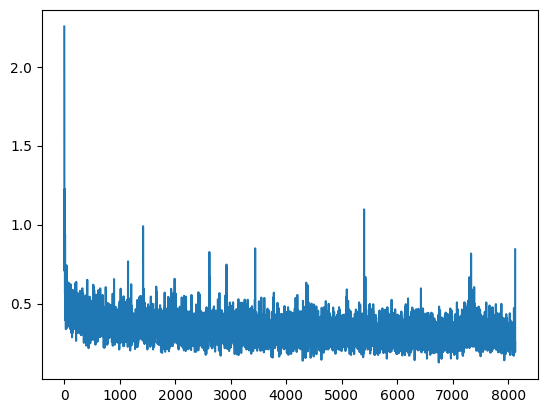

In [13]:
plt.plot(lossi);
# plt.show();

In [16]:
from collections import Counter

def show_class_distribution(dataset):
  labels = [label for _, label in dataset.samples]
  counts = Counter(labels)

  print("\nClass distribution:")
  for cls, count in counts.items():
    print(f"Class {cls}: {count}")

show_class_distribution(dataset)


Class distribution:
Class 0: 468356
Class 1: 268653
Class 2: 290420
Class 3: 4755
Class 4: 2296
Class 5: 5654


In [19]:
def compute_class_weights(dataset, num_classes):
  labels = [label for _, label in dataset.samples]
  counts = np.bincount(labels, minlength=num_classes)

  weights = 1.0 / (counts + 1e-6)
  weights = weights / weights.sum() * num_classes

  return torch.tensor(weights, dtype=torch.float).to(DEVICE)

class_weights = compute_class_weights(dataset, len(dataset.classes))


In [20]:
class_weights

tensor([0.0154, 0.0268, 0.0248, 1.5166, 3.1409, 1.2755], device='cuda:0')